# Background & Objectives

I recently came across a session by S&P Global on their use of GNNs & Nvidia Cugraph in a use case where the firm explores the ability to predict issuance of bonds (https://www.nvidia.com/en-us/on-demand/session/gtc25-s74726/) and due to the nature of the firm being a major data provider to most wall street shops on various packages and sectors, I figured that asset managers would certainly like to verify that the GNN model actually learns the underlying causal financial mechanisms instead of merely exploiting superficial structural correlations.

The graph being a large heterogeneous graph connecting companies, bonds, markets and clients presents a complex prediction challenge as the GNN model has to capture interaction between micro-level corporate needs (liquidity, debt financing) and macro-level market dynamics (investor demand, yeild curves..etc). 

This requires a sophisticated architecture that learns from node features as well as local & global neighborhood structures. Using any models that simply pool & aggregate features like GCNs or GraphSage would likely not fit the bill here as they'll oversmooth embeddings and perform poorly on smaller issuers or companies within the same large sectors (e.g. tech) where the companies share nearly identical maro exposures, patterns and balance sheets profiles.

Attenion is needed here to actually learn a weight for each connection an be able to differenciate between companies, sectors and different time periods.

Graph Attention Networks (GAT) in particular with their multi-attention heads can zero in on tracking independant financial dynamics simultaneously. Head 1 could track macro market liquidity, Head 2 can track balance sheet health...etc.

But how would we explain the results? For a prediction on a company issuing a bond, how can say with (some sort of) confidence that the bond is issued because of node features or because of structural similarities?

For this experiment I thought to take a deeper look at XAI (explainable AI methods) and try to understand if the attention coefficients learned match integrated gradients (IG), which are typically associated to influence.

The hypothesis here is if we had edges with a high IG and high attention, it would mean that the model has successfully learned local features with causal reality. If not, then the model has likely only learned structural redundancies.

To conduct this experiment, we'll be using CAPTUM (https://captum.ai/tutorials/Titanic_Basic_Interpret) a pytorch tool used to interpret models using integraded gradients. Read more on CAPTUM & IGs here (https://arxiv.org/pdf/2009.07896)


## The Very Brief Primer on Captum

-The objective of Captum is understanding feature importance. That could be the actual input features/columns, layer or even neuron importance.

-It works by repeatedly measuring gradients (dX/dtarget) for various inputs and outputs (i.e if I change this input X by dX, how much will it change the output prediction changes). Captum computes these gradients starting from baseline input all the way to the predicted value. Captum then averages these gradients  then multiplies the result by the difference between the input and the baseline.

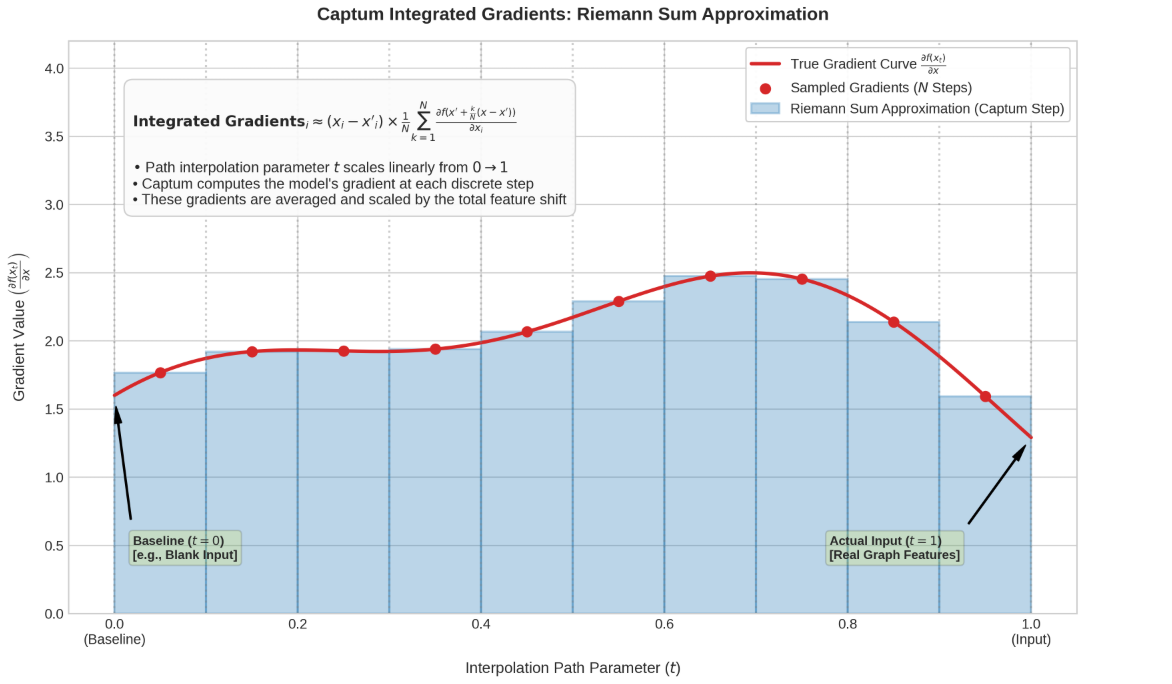

# Experiment

In [2]:
import os
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GATConv
import torch_geometric.transforms as T

In [3]:
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Data Loading

In [4]:
dataset = Planetoid(root='/tmp/Cora', name='Cora', transform=T.AddSelfLoops())
data = dataset[0].to(device)

Processing...
Done!


- We need to return the GAT's raw attention coefficients during training

- We need to allow Captum to access and scale the input edges so that it can compute the integrated gradients 

## Model

In [7]:
class ExplainableGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super().__init__()

        #typical GAT layers with edge_dim=1 to account for weight/edge for it to be modified by Captum
        #we also need to disable adding self loops so that captum can focus on input edges only
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6, edge_dim=1, add_self_loops=False)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, edge_dim=1, add_self_loops=False)

    def forward(self, x, edge_index, edge_mask=None):

        
        if edge_mask is None:
            edge_mask = torch.ones(edge_index.size(1), 1, device=x.device)
        else:
            #captum needs to pass a mask tensor to build the path integral
            #captum will repeatedly call this part to build to compute path integral of the gradients
            if edge_mask.dim() == 1:
                edge_mask = edge_mask.unsqueeze(-1)

        #returning topolgy raw attention coefficients/weights instead of typical node features alone
        x, (edge_index_a1, alpha1) = self.conv1(x, edge_index, edge_attr=edge_mask, return_attention_weights=True)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        
        x, (edge_index_a2, alpha2) = self.conv2(x, edge_index_a1, edge_attr=edge_mask, return_attention_weights=True)
        return F.log_softmax(x, dim=-1), (edge_index_a1, alpha1)

In [9]:
import torch.nn.functional as F

## Training

In [10]:
#init model, optimizer and run training
model = ExplainableGAT(dataset.num_features, 8, dataset.num_classes, heads=8).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

model.train()
for epoch in range(40):
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

model.eval()
#extract topolgy and attention weights
out, (actual_edge_index, alpha_weights) = model(data.x, data.edge_index)

#average attention weights across 8 attention heads to get single att score per edge
mean_attention = alpha_weights.mean(dim=-1).detach()
num_edges = data.edge_index.size(1)

## High Degree Node Isolation

In [15]:
data.edge_index[0].bincount().argmax().item()

1358

In [16]:
#let's pick the node with the highest degree to analyze
target_node = int(data.edge_index[0].bincount().argmax().item())
target_class = out[target_node].argmax().item()

In [17]:
target_class

2

We need to create a wrapper function for Captum to use so that it's able to feed an arbitraty edge mask input to the forward pass and get an associated ouput log prob to a node

In [18]:
def captum_forward_wrapper(edge_mask_input, x, edge_index, target_node_idx):
    out, _ = model(x, edge_index, edge_mask_input)
    return out[target_node_idx].unsqueeze(0)

Let's now compute the Captum Integrated Gradients:

- The following will compute IGs by starting from checking performance on zero edges to all edges activated.

- It will use the wrapper function we create earlier to activate/deactivate edges

## Integrated Gradients

In [21]:
from captum.attr import IntegratedGradients

In [22]:
ig = IntegratedGradients(captum_forward_wrapper)
input_mask = torch.ones(num_edges, 1, device=device)
baseline_mask = torch.zeros(num_edges, 1, device=device)

ig_attributions = ig.attribute(
    inputs=input_mask,
    baselines=baseline_mask,
    additional_forward_args=(data.x, data.edge_index, target_node),
    target=target_class,
    internal_batch_size=1
)
ig_saliency = ig_attributions.abs().squeeze().cpu().detach()

/home/y/anaconda3/envs/gnn/lib/python3.10/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 13264 equal to the number of examples.
  warnings.warn(


We are now in a position to check if the attention coeffiecients are in fact also explanatory or not. We will do so by deleting various percentages of edges in both attention and IGs and see how that impacts accuracy

# Results

In [24]:
import matplotlib.pyplot as plt

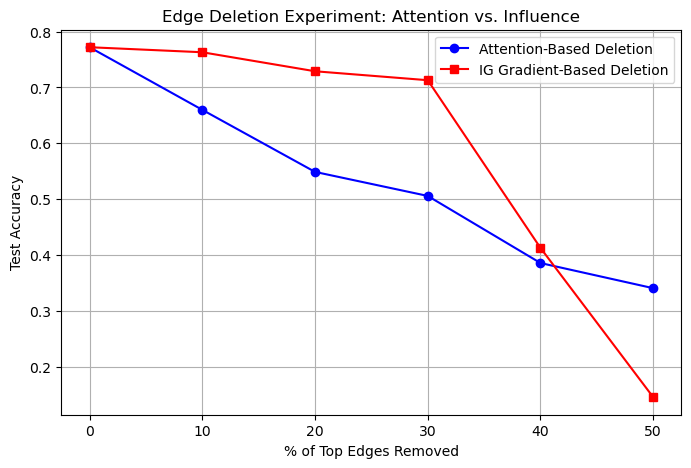

In [25]:
def evaluate_with_deleted_edges(sort_indices, percentages, data, model):
    accuracies = []
    
    for p in percentages:
        num_to_remove = int(num_edges * (p / 100.0))
        edges_to_keep = sort_indices[num_to_remove:]
        masked_edge_index = data.edge_index[:, edges_to_keep]
        
        with torch.no_grad():
            pred, _ = model(data.x, masked_edge_index)
            correct = float(pred[data.test_mask].argmax(dim=-1).eq(data.y[data.test_mask]).sum().item())
            acc = correct / int(data.test_mask.sum())
            accuracies.append(acc)
    return accuracies

percentages = [0, 10, 20, 30, 40, 50]

attn_sort = torch.argsort(mean_attention, descending=True).cpu()
ig_sort = torch.argsort(ig_saliency, descending=True).cpu()

acc_attn = evaluate_with_deleted_edges(attn_sort, percentages, data, model)
acc_ig = evaluate_with_deleted_edges(ig_sort, percentages, data, model)

plt.figure(figsize=(8, 5))
plt.plot(percentages, acc_attn, marker='o', label='Attention-Based Deletion', color='blue')
plt.plot(percentages, acc_ig, marker='s', label='IG Gradient-Based Deletion', color='red')
plt.xlabel('% of Top Edges Removed')
plt.ylabel('Test Accuracy')
plt.title('Edge Deletion Experiment: Attention vs. Influence')
plt.grid(True)
plt.legend()
plt.show()

- As we removed high attention edges (blue line), the accuracy dropped. Which means that the edges that the model paid most attention are in fact capturing core information.

- For IG gradients, we observe an interesting progress. Removal of high IG edges didn't truly impact performance, which might mean that the model has also learned redundant paths in the graph. The same message was able to travel through multiple paths in the graph.

- Going back to our Bond issuance example, if we were to use a GAT to predict issuance, we would be more confident in instances where attention is high and IGs are low since we can now say with (some level of) confidence that IGs are not representative of true causality.

- If the GAT was used to predict issuance, it would be somewhat of a herding predictor. A model that spotts industry-wide issuance waves and not individual companies.

- if we wanted to compress this model for production, we could safuly prune these high IG edges which actually make the model more optimized in its predictions since it relies on essential paths only.

- This experiment proved our initial hypothesis wrong, in which we assumed that we should trust instances where high IG and high attention are predictors of causality.